In [11]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# Import Required Libraries
import os
import string
import pickle
import numpy as np

from collections import Counter
from tqdm import tqdm

In [16]:
# Define Project Paths
PROJECT_PATH = "/content/drive/MyDrive/DL_HW2_ImageCaptioning"

IMAGE_PATH = PROJECT_PATH + "/dataset/images/Images"

TEXT_PATH = PROJECT_PATH + "/dataset/text"

CAPTION_FILE = TEXT_PATH + "/Flickr8k.token.txt"

TRAIN_FILE = TEXT_PATH + "/Flickr_8k.trainImages.txt"

FEATURE_PATH = PROJECT_PATH + "/features/features.pkl"

In [17]:
# Load Caption Dataset
with open(CAPTION_FILE, "r") as f:
    text = f.read()

print(len(text))

3395237


In [18]:
# Parse Image Captions
def load_descriptions(text):

    descriptions = {}

    for line in text.split("\n"):

        if len(line) < 2:
            continue

        tokens = line.split("\t")

        if len(tokens) != 2:
            continue

        image_id, caption = tokens

        image_id = image_id.split("#")[0]

        descriptions.setdefault(image_id, []).append(caption)

    return descriptions


descriptions = load_descriptions(text)

print(len(descriptions))

8092


In [19]:
# Clean and Preprocess Captions
table = str.maketrans('', '', string.punctuation)

for image_id, captions in descriptions.items():

    clean = []

    for caption in captions:

        words = caption.lower().split()

        words = [w.translate(table) for w in words]

        words = [w for w in words if w.isalpha()]

        words = [w for w in words if len(w) > 1]

        clean.append(" ".join(words))

    descriptions[image_id] = clean

In [20]:
# Save Clean Captions
clean_file = PROJECT_PATH + "/captions/descriptions.txt"

with open(clean_file, "w") as f:

    for image_id, captions in descriptions.items():

        for caption in captions:

            f.write(image_id + "\t" + caption + "\n")

print("Saved")

Saved


In [21]:
# Build Vocabulary
counter = Counter()

for captions in descriptions.values():

    for caption in captions:

        counter.update(caption.split())

threshold = 10

vocabulary = sorted([w for w, c in counter.items() if c >= threshold])

print("Vocabulary:", len(vocabulary))

Vocabulary: 1947


In [22]:
# Create Word Index Mappings
word2idx = {"<PAD>":0}

idx2word = {0:"<PAD>"}

for word in vocabulary:

    index = len(word2idx)

    word2idx[word] = index

    idx2word[index] = word

word2idx["<START>"] = len(word2idx)
idx2word[word2idx["<START>"]] = "<START>"

word2idx["<END>"] = len(word2idx)
idx2word[word2idx["<END>"]] = "<END>"

print(len(word2idx))

1950


In [23]:
# Prepare Training Dataset
with open(TRAIN_FILE) as f:

    train_images = f.read().splitlines()

train_descriptions = {}

for image in train_images:

    if image in descriptions:

        train_descriptions[image] = [

            "<START> " + c + " <END>"

            for c in descriptions[image]

        ]

print(len(train_images))

print(len(train_descriptions))

6000
6000


In [24]:
# Build VGG16 Feature Extractor
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Model

base_model = VGG16(weights="imagenet")

model = Model(
    inputs=base_model.inputs,
    outputs=base_model.get_layer("fc2").output
)

print(model.output_shape)

(None, 4096)


In [76]:
# Extract Image Features
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

import numpy as np

def encode_image(filename):

    image = load_img(filename, target_size=(224,224))

    image = img_to_array(image)

    image = np.expand_dims(image, axis=0)

    image = preprocess_input(image)

    feature = feature_extractor.predict(image, verbose=0)

    return feature.flatten()

In [26]:
# Verify Feature Extraction
sample_image = IMAGE_PATH + "/" + train_images[0]

feature = encode_image(sample_image)

print(feature.shape)

(4096,)


In [27]:
# Extract Features from Training Images
from tqdm import tqdm
import pickle
import os

features = {}

for image_name in tqdm(train_images):

    image_path = os.path.join(IMAGE_PATH, image_name)

    try:

        features[image_name] = encode_image(image_path)

    except Exception as e:

        print(f"Error processing {image_name}: {e}")

print("Number of extracted features:", len(features))

100%|██████████| 6000/6000 [45:45<00:00,  2.19it/s]

Number of extracted features: 6000


In [28]:
# Save Extracted Features
with open(FEATURE_PATH, "wb") as f:
    pickle.dump(features, f)

print("Features saved successfully.")

Features saved successfully.


In [29]:
# Load Extracted Image Features
with open(FEATURE_PATH, "rb") as f:
    features = pickle.load(f)

print("Loaded Features:", len(features))

Loaded Features: 6000


In [30]:
# Determine Maximum Caption Length
max_length = max(
    len(caption.split())
    for captions in train_descriptions.values()
    for caption in captions
)

print("Maximum Caption Length:", max_length)

Maximum Caption Length: 34


In [31]:
# Create Word Index Mappings
vocab_size = len(word2idx)

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 1950


In [32]:

def caption_to_sequence(caption, word2idx):

    sequence = []

    for word in caption.split():

        if word in word2idx:
            sequence.append(word2idx[word])

    return sequence

In [34]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [35]:
def create_training_sample(sequence, photo, max_length, vocab_size):

    X1, X2, y = [], [], []

    for i in range(1, len(sequence)):

        in_seq = sequence[:i]

        out_seq = sequence[i]

        in_seq = pad_sequences(
            [in_seq],
            maxlen=max_length
        )[0]

        out_seq = to_categorical(
            out_seq,
            num_classes=vocab_size
        )

        X1.append(photo)
        X2.append(in_seq)
        y.append(out_seq)

    return np.array(X1), np.array(X2), np.array(y)

In [37]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Add

In [38]:
image_input = Input(shape=(4096,), name="image_input")

image_features = Dropout(0.5)(image_input)

image_features = Dense(
    256,
    activation="relu"
)(image_features)

In [59]:
text_input = Input(
    shape=(max_length,),
    name="text_input"
)

text_features = Embedding(
    input_dim=vocab_size,
    output_dim=256,
    mask_zero=False
)(text_input)

text_features = Dropout(0.5)(text_features)

text_features = LSTM(256)(text_features)

In [60]:
decoder = Add()([
    image_features,
    text_features
])

decoder = Dense(
    256,
    activation="relu"
)(decoder)

output = Dense(
    vocab_size,
    activation="softmax"
)(decoder)

In [61]:
model = Model(
    inputs=[image_input, text_input],
    outputs=output
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 34, 256)   │    499,200 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4096)      │          0 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 34, 256)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,048,832 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 256)       │    525,312 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     65,792 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1950)      │    501,150 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,640,286 (10.07 MB)

 Trainable params: 2,640,286 (10.07 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np

In [63]:
class DataGenerator(Sequence):

    def __init__(
        self,
        descriptions,
        features,
        word2idx,
        max_length,
        vocab_size,
        batch_size=32,
        shuffle=True
    ):

        self.descriptions = descriptions
        self.features = features
        self.word2idx = word2idx
        self.max_length = max_length
        self.vocab_size = vocab_size
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.image_ids = list(descriptions.keys())

        self.on_epoch_end()

    def __len__(self):

        return int(np.ceil(len(self.image_ids) / self.batch_size))

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.image_ids)

    def __getitem__(self, index):

        batch_ids = self.image_ids[
            index*self.batch_size:(index+1)*self.batch_size
        ]

        X1, X2, y = [], [], []

        for image_id in batch_ids:

            photo = self.features[image_id]

            for caption in self.descriptions[image_id]:

                sequence = [
                    self.word2idx[w]
                    for w in caption.split()
                    if w in self.word2idx
                ]

                for i in range(1, len(sequence)):

                    in_seq = sequence[:i]

                    out_seq = sequence[i]

                    in_seq = pad_sequences(
                        [in_seq],
                        maxlen=self.max_length
                    )[0]

                    out_seq = to_categorical(
                        out_seq,
                        num_classes=self.vocab_size
                    )

                    X1.append(photo)
                    X2.append(in_seq)
                    y.append(out_seq)

        return (
            (
                np.array(X1, dtype=np.float32),
                np.array(X2, dtype=np.int32),
            ),
            np.array(y, dtype=np.float32),
        )

In [64]:
generator = DataGenerator(
    train_descriptions,
    features,
    word2idx,
    max_length,
    vocab_size,
    batch_size=16
)

(X_img, X_seq), y = generator[0]

print(X_img.shape)
print(X_seq.shape)
print(y.shape)

(845, 4096)
(845, 34)
(845, 1950)


In [65]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [66]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

checkpoint = ModelCheckpoint(
    PROJECT_PATH + "/best_model.keras",
    monitor="loss",
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor="loss",
    patience=3,
    restore_best_weights=True
)

callbacks = [
    checkpoint,
    earlystop
]

In [67]:
train_generator = DataGenerator(
    descriptions=train_descriptions,
    features=features,
    word2idx=word2idx,
    max_length=max_length,
    vocab_size=vocab_size,
    batch_size=32,
    shuffle=True
)

In [69]:
history = model.fit(
    train_generator,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.1222 - loss: 5.4200
Epoch 1: loss improved from None to 4.83662, saving model to /content/drive/MyDrive/DL_HW2_ImageCaptioning/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DL_HW2_ImageCaptioning/best_model.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 22s 107ms/step - accuracy: 0.1664 - loss: 4.8366
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.2568 - loss: 3.8230
Epoch 2: loss improved from 4.83662 to 3.73704, saving model to /content/drive/MyDrive/DL_HW2_ImageCaptioning/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DL_HW2_ImageCaptioning/best_model.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - accuracy: 0.2662 - loss: 3.7370
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.2942 - loss: 3.4193
Epoch 3: loss improved from 3.73704 to 3.38848, saving model to /content/drive/MyDrive/DL_HW2_ImageCaptioning/best_model.keras

Epoch

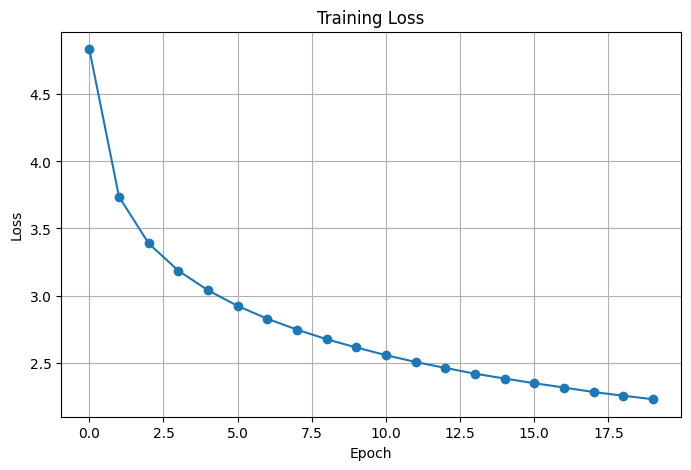

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


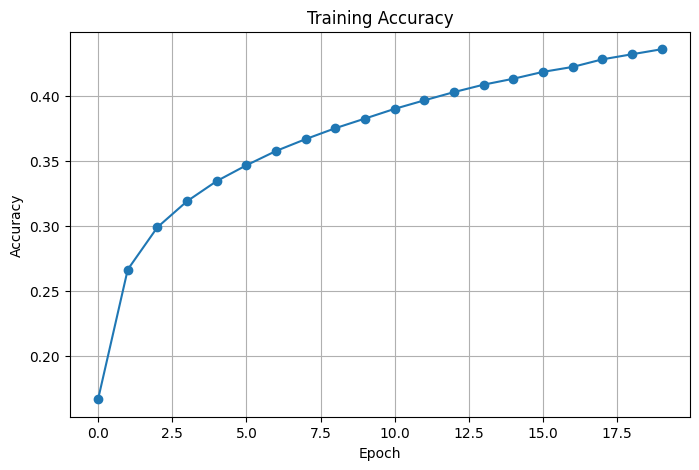

In [71]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], marker="o")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [72]:
from tensorflow.keras.models import load_model

model = load_model(PROJECT_PATH + "/best_model.keras")

print("Model Loaded Successfully")

Model Loaded Successfully


In [73]:
TEST_FILE = os.path.join(
    TEXT_PATH,
    "Flickr_8k.testImages.txt"
)

with open(TEST_FILE, "r") as f:
    test_images = f.read().splitlines()

print("Number of Test Images:", len(test_images))

Number of Test Images: 1000


In [77]:
test_features = {}

for image_name in tqdm(test_images):

    image_path = os.path.join(
        IMAGE_PATH,
        image_name
    )

    test_features[image_name] = encode_image(image_path)

print("Extracted Test Features:", len(test_features))

100%|██████████| 1000/1000 [07:33<00:00,  2.20it/s]

Extracted Test Features: 1000


In [78]:
with open(PROJECT_PATH + "/test_features.pkl", "wb") as f:
    pickle.dump(test_features, f)

print("Test features saved.")

Test features saved.


In [79]:
def idx_to_word(integer, idx2word):

    return idx2word.get(integer, None)

In [80]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def generate_caption(photo_feature):

    in_text = "<START>"

    for i in range(max_length):

        sequence = []

        for word in in_text.split():

            if word in word2idx:
                sequence.append(word2idx[word])

        sequence = pad_sequences(
            [sequence],
            maxlen=max_length
        )

        yhat = model.predict(
            [photo_feature.reshape((1,4096)), sequence],
            verbose=0
        )

        yhat = np.argmax(yhat)

        word = idx_to_word(yhat, idx2word)

        if word is None:
            break

        in_text += " " + word

        if word == "<END>":
            break

    return in_text

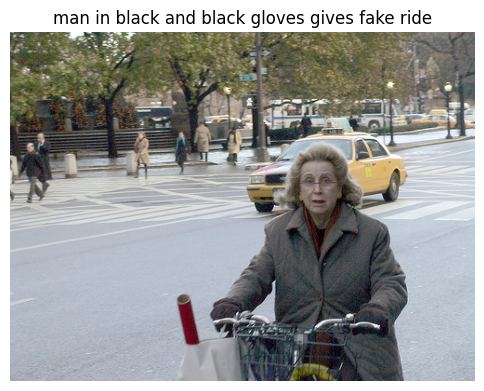

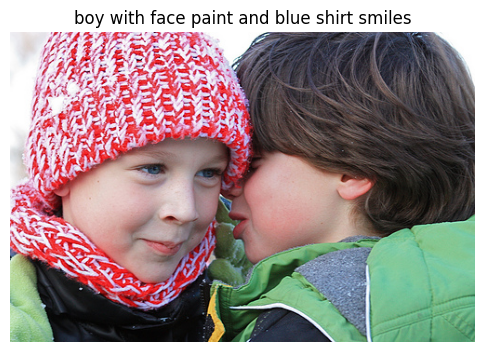

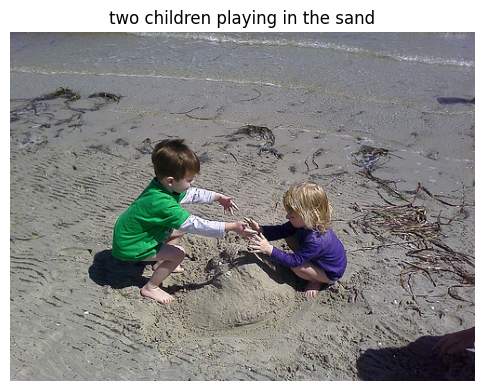

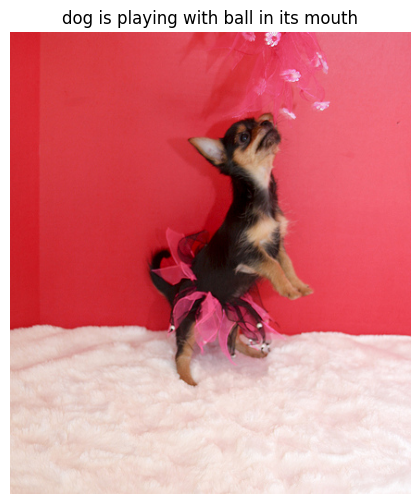

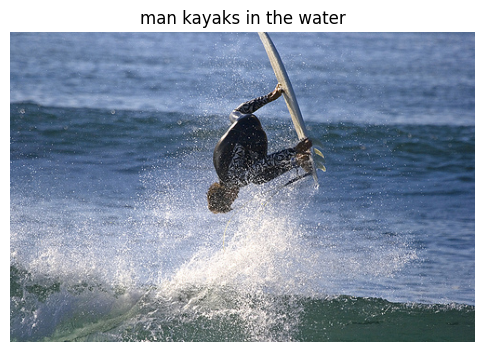

In [86]:
import random

random_images = random.sample(test_images, 5)

for image_name in random_images:

    img = load_img(os.path.join(IMAGE_PATH, image_name))

    caption = generate_caption(test_features[image_name])

    caption = caption.replace("<START>", "")
    caption = caption.replace("<END>", "")
    caption = caption.strip()

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(caption, fontsize=12)
    plt.show()

In [87]:
model.save(PROJECT_PATH + "/final_model.keras")